# Hybrid Model: PhoBERT + TF-IDF

## Mô tả
Notebook này triển khai mô hình hybrid kết hợp:
- **PhoBERT embeddings**: Pre-trained deep learning features
- **TF-IDF features**: Statistical textual features

**Đặc điểm:**
- Sử dụng PhoBERT baseline model đã train sẵn (freeze weights)
- Thêm TF-IDF features để bổ sung thông tin thống kê
- Kết hợp late fusion (combine predictions/features)

**Mục đích:** Tăng hiệu suất bằng cách kết hợp strengths của cả 2 phương pháp.

## 1. Setup và Import Libraries

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
!pip install transformers torch scikit-learn matplotlib seaborn underthesea

In [29]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import pickle
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


In [30]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

## 2. Configuration

In [31]:
class Config:
    BASE_DIR = '/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis'
    DATA_DIR = f'{BASE_DIR}/data/processed'
    RESULTS_DIR = f'{BASE_DIR}/results/TF_IDF_Hybrid'
    PHOBERT_MODEL_DIR = f'{BASE_DIR}/results/PhoBERT_Baseline/phobert_baseline_model.pt'
    MODEL_NAME = 'vinai/phobert-base'
    MAX_LENGTH = 256
    BATCH_SIZE = 32
    NUM_CLASSES = 3
    TFIDF_MAX_FEATURES = 5000
    TFIDF_NGRAM_RANGE = (1, 2)
    LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

config = Config()
os.makedirs(config.RESULTS_DIR, exist_ok=True)
print(f'Results will be saved to: {config.RESULTS_DIR}')
print(f'Device: {config.DEVICE}')

Results will be saved to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/TF_IDF_Hybrid
Device: cuda


## 3. Load Data

In [32]:
def load_data(data_dir, split):
    split_dir = os.path.join(data_dir, split)
    with open(os.path.join(split_dir, 'sents.txt'), 'r', encoding='utf-8') as f:
        texts = [line.strip() for line in f.readlines()]
    with open(os.path.join(split_dir, 'sentiments.txt'), 'r', encoding='utf-8') as f:
        labels = [int(line.strip()) for line in f.readlines()]
    print(f'{split}: {len(texts)} samples')
    return texts, labels

train_texts, train_labels = load_data(config.DATA_DIR, 'train')
val_texts, val_labels = load_data(config.DATA_DIR, 'validation')
test_texts, test_labels = load_data(config.DATA_DIR, 'test')

train: 11426 samples
validation: 1583 samples
test: 3166 samples


In [33]:
from collections import Counter

print('Label distribution:')
for split_name, labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    counter = Counter(labels)
    print(f'{split_name}:')
    for label, count in sorted(counter.items()):
        print(f'  {config.LABEL_MAP[label]}: {count} ({count/len(labels)*100:.1f}%)')

Label distribution:
Train:
  Negative: 5325 (46.6%)
  Neutral: 458 (4.0%)
  Positive: 5643 (49.4%)
Val:
  Negative: 705 (44.5%)
  Neutral: 73 (4.6%)
  Positive: 805 (50.9%)
Test:
  Negative: 1409 (44.5%)
  Neutral: 167 (5.3%)
  Positive: 1590 (50.2%)


## 4. PhoBERT Model Definition (Load from checkpoint)

In [34]:
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
print(f'Tokenizer loaded: {config.MODEL_NAME}')

Tokenizer loaded: vinai/phobert-base


In [35]:
class PhoBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.1):
        super(PhoBERTClassifier, self).__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return logits, pooled_output

    def extract_embeddings(self, input_ids, attention_mask):
        """Extract embeddings without classification head"""
        with torch.no_grad():
            outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
            pooled_output = outputs.last_hidden_state[:, 0, :]
        return pooled_output

In [36]:
def load_model_safe(model, checkpoint_path, device):
    """
    Load model state_dict với xử lý các trường hợp đặc biệt:
    - Checkpoint có prefix "module." (từ DataParallel)
    - Checkpoint chứa metadata
    """
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    if isinstance(checkpoint, dict):
        if 'state_dict' in checkpoint:
            state_dict = checkpoint['state_dict']
        elif 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint
    else:
        state_dict = checkpoint

    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith('module.'):
            new_state_dict[k[7:]] = v
        else:
            new_state_dict[k] = v

    model.load_state_dict(new_state_dict)
    return model

# Load PhoBERT baseline model
print('📥 Loading PhoBERT Baseline model...')
phobert_model = PhoBERTClassifier(model_name=config.MODEL_NAME, num_classes=config.NUM_CLASSES)
phobert_model = load_model_safe(phobert_model, config.PHOBERT_MODEL_DIR, config.DEVICE)
phobert_model = phobert_model.to(config.DEVICE)

# Freeze PhoBERT parameters - chỉ dùng để extract features
for param in phobert_model.parameters():
    param.requires_grad = False
phobert_model.eval()
print('✅ PhoBERT model loaded and frozen for feature extraction!')

📥 Loading PhoBERT Baseline model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ PhoBERT model loaded and frozen for feature extraction!


## 5. Dataset Class cho Hybrid Model

In [37]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

## 6. TF-IDF Feature Extraction

In [38]:
# Vietnamese text preprocessing
import re

def preprocess_vietnamese(text):
    """Basic preprocessing for Vietnamese text"""
    # Convert to lowercase
    text = text.lower()
    # Remove special characters but keep Vietnamese accents
    text = re.sub(r'[^\w\sàáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ]', ' ', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

# Preprocess all texts
train_texts_processed = [preprocess_vietnamese(t) for t in train_texts]
val_texts_processed = [preprocess_vietnamese(t) for t in val_texts]
test_texts_processed = [preprocess_vietnamese(t) for t in test_texts]

print('📝 Creating TF-IDF vectorizer...')
tfidf_vectorizer = TfidfVectorizer(
    max_features=config.TFIDF_MAX_FEATURES,
    ngram_range=config.TFIDF_NGRAM_RANGE,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Fit on training data only
train_tfidf = tfidf_vectorizer.fit_transform(train_texts_processed)
val_tfidf = tfidf_vectorizer.transform(val_texts_processed)
test_tfidf = tfidf_vectorizer.transform(test_texts_processed)

print(f'   TF-IDF train shape: {train_tfidf.shape}')
print(f'   TF-IDF val shape: {val_tfidf.shape}')
print(f'   TF-IDF test shape: {test_tfidf.shape}')

# Save TF-IDF vectorizer
with open(os.path.join(config.RESULTS_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print(f'✅ TF-IDF vectorizer saved!')

📝 Creating TF-IDF vectorizer...
   TF-IDF train shape: (11426, 5000)
   TF-IDF val shape: (1583, 5000)
   TF-IDF test shape: (3166, 5000)
✅ TF-IDF vectorizer saved!


## 7. Extract PhoBERT Embeddings

In [39]:
def extract_phobert_embeddings(model, texts, tokenizer, device, batch_size=32):
    """Extract PhoBERT embeddings for all texts"""
    model.eval()
    all_embeddings = []

    dataloader = DataLoader(
        SentimentDataset(texts, [0]*len(texts), tokenizer, config.MAX_LENGTH),
        batch_size=batch_size,
        shuffle=False
    )

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Extracting embeddings'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            embeddings = model.extract_embeddings(input_ids, attention_mask)
            all_embeddings.append(embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

from tqdm import tqdm

print('🔄 Extracting PhoBERT embeddings for train set...')
train_phobert_emb = extract_phobert_embeddings(phobert_model, train_texts, tokenizer, config.DEVICE, config.BATCH_SIZE)
print(f'   Train embeddings shape: {train_phobert_emb.shape}')

print('🔄 Extracting PhoBERT embeddings for val set...')
val_phobert_emb = extract_phobert_embeddings(phobert_model, val_texts, tokenizer, config.DEVICE, config.BATCH_SIZE)
print(f'   Val embeddings shape: {val_phobert_emb.shape}')

print('🔄 Extracting PhoBERT embeddings for test set...')
test_phobert_emb = extract_phobert_embeddings(phobert_model, test_texts, tokenizer, config.DEVICE, config.BATCH_SIZE)
print(f'   Test embeddings shape: {test_phobert_emb.shape}')

print('✅ PhoBERT embeddings extracted!')

🔄 Extracting PhoBERT embeddings for train set...


Extracting embeddings: 100%|██████████| 358/358 [02:28<00:00,  2.41it/s]


   Train embeddings shape: (11426, 768)
🔄 Extracting PhoBERT embeddings for val set...


Extracting embeddings: 100%|██████████| 50/50 [00:20<00:00,  2.43it/s]


   Val embeddings shape: (1583, 768)
🔄 Extracting PhoBERT embeddings for test set...


Extracting embeddings: 100%|██████████| 99/99 [00:40<00:00,  2.47it/s]

   Test embeddings shape: (3166, 768)
✅ PhoBERT embeddings extracted!


## 8. Combine Features và Train Hybrid Classifier

In [40]:
# Combine PhoBERT embeddings with TF-IDF features
def combine_features(phobert_emb, tfidf_features):
    """
    Combine PhoBERT embeddings with TF-IDF features
    - PhoBERT: (n_samples, 768)
    - TF-IDF: (n_samples, n_tfidf_features)
    """
    # Convert sparse TF-IDF to dense
    tfidf_dense = tfidf_features.toarray()
    # Concatenate
    combined = np.hstack([phobert_emb, tfidf_dense])
    return combined

print('🔗 Combining PhoBERT + TF-IDF features...')
train_combined = combine_features(train_phobert_emb, train_tfidf)
val_combined = combine_features(val_phobert_emb, val_tfidf)
test_combined = combine_features(test_phobert_emb, test_tfidf)

print(f'   Train combined shape: {train_combined.shape}')
print(f'   Val combined shape: {val_combined.shape}')
print(f'   Test combined shape: {test_combined.shape}')

🔗 Combining PhoBERT + TF-IDF features...
   Train combined shape: (11426, 5768)
   Val combined shape: (1583, 5768)
   Test combined shape: (3166, 5768)


In [41]:
# Scale features
print('⚙️ Scaling features...')
scaler = StandardScaler()
train_combined_scaled = scaler.fit_transform(train_combined)
val_combined_scaled = scaler.transform(val_combined)
test_combined_scaled = scaler.transform(test_combined)

# Save scaler
with open(os.path.join(config.RESULTS_DIR, 'feature_scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print('✅ Features scaled!')

⚙️ Scaling features...
✅ Features scaled!


In [42]:
# Train Logistic Regression on combined features
print('🚂 Training Logistic Regression on combined features...')
hybrid_model = LogisticRegression(
    multi_class='multinomial',
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    C=1.0,
    class_weight='balanced'
)

hybrid_model.fit(train_combined_scaled, train_labels)
print('✅ Hybrid model trained!')

🚂 Training Logistic Regression on combined features...
✅ Hybrid model trained!


## 9. Evaluate Hybrid Model

In [43]:
# Predictions
train_preds = hybrid_model.predict(train_combined_scaled)
val_preds = hybrid_model.predict(val_combined_scaled)
test_preds = hybrid_model.predict(test_combined_scaled)

# Probabilities
train_probs = hybrid_model.predict_proba(train_combined_scaled)
val_probs = hybrid_model.predict_proba(val_combined_scaled)
test_probs = hybrid_model.predict_proba(test_combined_scaled)

In [44]:
# Calculate metrics
train_acc = accuracy_score(train_labels, train_preds)
train_f1 = f1_score(train_labels, train_preds, average='weighted')

val_acc = accuracy_score(val_labels, val_preds)
val_f1 = f1_score(val_labels, val_preds, average='weighted')

test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, average='weighted')

print('='*60)
print('📊 HYBRID MODEL RESULTS (PhoBERT + TF-IDF)')
print('='*60)
print(f'Train - Accuracy: {train_acc:.4f}, F1: {train_f1:.4f}')
print(f'Val   - Accuracy: {val_acc:.4f}, F1: {val_f1:.4f}')
print(f'Test  - Accuracy: {test_acc:.4f}, F1: {test_f1:.4f}')

📊 HYBRID MODEL RESULTS (PhoBERT + TF-IDF)
Train - Accuracy: 0.9999, F1: 0.9999
Val   - Accuracy: 0.9375, F1: 0.9375
Test  - Accuracy: 0.9308, F1: 0.9298


In [45]:
print('\nClassification Report (Test):')
target_names = [config.LABEL_MAP[i] for i in range(config.NUM_CLASSES)]
print(classification_report(test_labels, test_preds, target_names=target_names, digits=4))


Classification Report (Test):
              precision    recall  f1-score   support

    Negative     0.9393    0.9553    0.9472      1409
     Neutral     0.6309    0.5629    0.5949       167
    Positive     0.9514    0.9478    0.9496      1590

    accuracy                         0.9308      3166
   macro avg     0.8405    0.8220    0.8306      3166
weighted avg     0.9291    0.9308    0.9298      3166



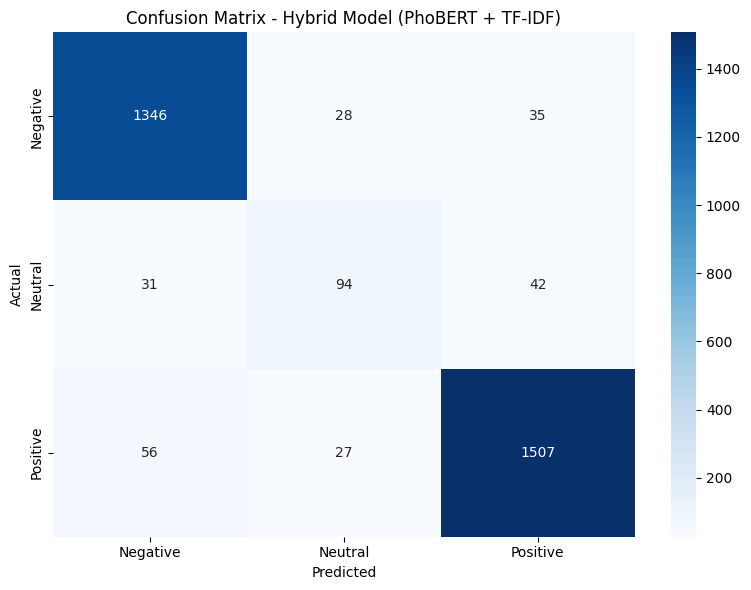

In [46]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Hybrid Model (PhoBERT + TF-IDF)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

## 10. Compare với các model riêng lẻ

In [47]:
# Train individual models for comparison

# 1. PhoBERT only (using embeddings + LR)
print('📊 Training PhoBERT-only model...')
phobert_only_model = LogisticRegression(
    multi_class='multinomial',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
scaler_phobert = StandardScaler()
train_phobert_scaled = scaler_phobert.fit_transform(train_phobert_emb)
test_phobert_scaled = scaler_phobert.transform(test_phobert_emb)
phobert_only_model.fit(train_phobert_scaled, train_labels)
phobert_test_preds = phobert_only_model.predict(test_phobert_scaled)
phobert_test_acc = accuracy_score(test_labels, phobert_test_preds)
phobert_test_f1 = f1_score(test_labels, phobert_test_preds, average='weighted')
print(f'   PhoBERT Only - Acc: {phobert_test_acc:.4f}, F1: {phobert_test_f1:.4f}')

# 2. TF-IDF only
print('📊 Training TF-IDF-only model...')
tfidf_only_model = LogisticRegression(
    multi_class='multinomial',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
scaler_tfidf = StandardScaler()
train_tfidf_scaled = scaler_tfidf.fit_transform(train_tfidf.toarray())
test_tfidf_scaled = scaler_tfidf.transform(test_tfidf.toarray())
tfidf_only_model.fit(train_tfidf_scaled, train_labels)
tfidf_test_preds = tfidf_only_model.predict(test_tfidf_scaled)
tfidf_test_acc = accuracy_score(test_labels, tfidf_test_preds)
tfidf_test_f1 = f1_score(test_labels, tfidf_test_preds, average='weighted')
print(f'   TF-IDF Only - Acc: {tfidf_test_acc:.4f}, F1: {tfidf_test_f1:.4f}')

📊 Training PhoBERT-only model...
   PhoBERT Only - Acc: 0.9283, F1: 0.9262
📊 Training TF-IDF-only model...
   TF-IDF Only - Acc: 0.8509, F1: 0.8514


In [48]:
import pandas as pd

# Comparison table
comparison = {
    'Model': ['PhoBERT Only', 'TF-IDF Only', 'Hybrid (PhoBERT + TF-IDF)'],
    'Test Accuracy': [phobert_test_acc, tfidf_test_acc, test_acc],
    'Test F1 (weighted)': [phobert_test_f1, tfidf_test_f1, test_f1]
}

comparison_df = pd.DataFrame(comparison)
print('\n' + '='*60)
print('📊 MODEL COMPARISON')
print('='*60)
print(comparison_df.to_string(index=False))

# Save comparison
comparison_df.to_csv(os.path.join(config.RESULTS_DIR, 'model_comparison.csv'), index=False)


📊 MODEL COMPARISON
                    Model  Test Accuracy  Test F1 (weighted)
             PhoBERT Only       0.928301            0.926190
              TF-IDF Only       0.850916            0.851440
Hybrid (PhoBERT + TF-IDF)       0.930828            0.929828


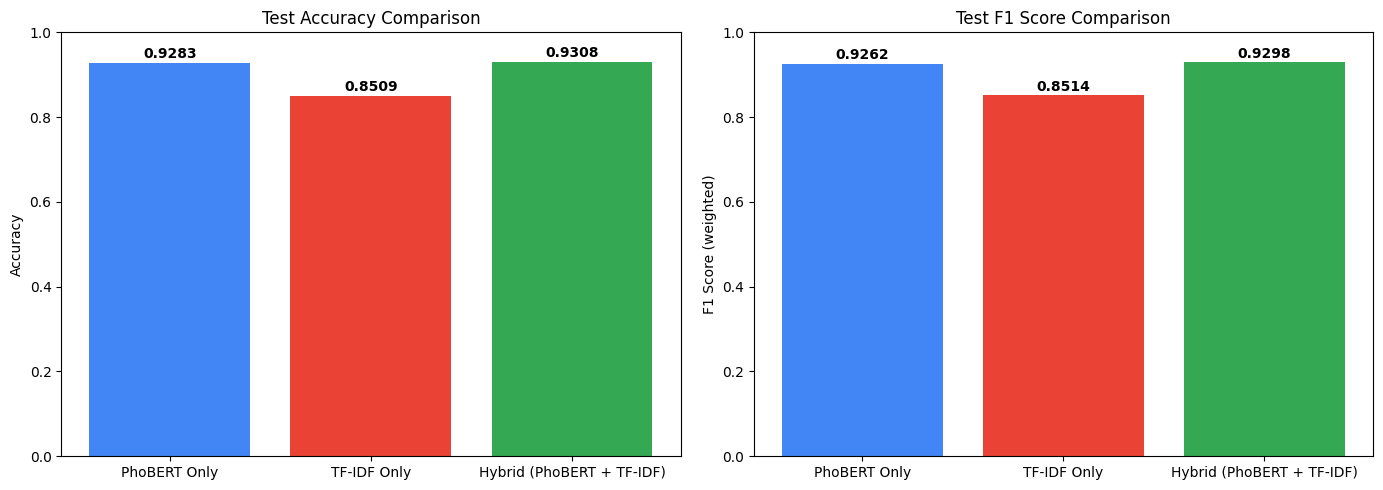

In [49]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].bar(comparison['Model'], comparison['Test Accuracy'], color=['#4285F4', '#EA4335', '#34A853'])
axes[0].set_title('Test Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
for i, v in enumerate(comparison['Test Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# F1 comparison
axes[1].bar(comparison['Model'], comparison['Test F1 (weighted)'], color=['#4285F4', '#EA4335', '#34A853'])
axes[1].set_title('Test F1 Score Comparison')
axes[1].set_ylabel('F1 Score (weighted)')
axes[1].set_ylim(0, 1)
for i, v in enumerate(comparison['Test F1 (weighted)']):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'model_comparison.png'), dpi=150)
plt.show()

## 11. Save Hybrid Model

In [50]:
# Save the hybrid model
with open(os.path.join(config.RESULTS_DIR, 'hybrid_model.pkl'), 'wb') as f:
    pickle.dump(hybrid_model, f)
print('✅ Hybrid model saved!')

✅ Hybrid model saved!


In [51]:
# Save summary
summary = {
    'Model': 'Hybrid (PhoBERT + TF-IDF)',
    'PhoBERT Model': 'vinai/phobert-base (pretrained)',
    'TF-IDF Features': config.TFIDF_MAX_FEATURES,
    'TF-IDF N-gram': f'{config.TFIDF_NGRAM_RANGE[0]}-{config.TFIDF_NGRAM_RANGE[1]}',
    'Combined Features': train_combined.shape[1],
    'Classifier': 'Logistic Regression',
    'Train Accuracy': train_acc,
    'Val Accuracy': val_acc,
    'Test Accuracy': test_acc,
    'Test F1 (weighted)': test_f1
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(os.path.join(config.RESULTS_DIR, 'hybrid_summary.csv'), index=False)

print('\n' + '='*60)
print('📁 SUMMARY - Hybrid Model')
print('='*60)
for key, value in summary.items():
    if isinstance(value, float):
        print(f'{key}: {value:.4f}')
    else:
        print(f'{key}: {value}')

print(f'\n✅ All results saved to: {config.RESULTS_DIR}')


📁 SUMMARY - Hybrid Model
Model: Hybrid (PhoBERT + TF-IDF)
PhoBERT Model: vinai/phobert-base (pretrained)
TF-IDF Features: 5000
TF-IDF N-gram: 1-2
Combined Features: 5768
Classifier: Logistic Regression
Train Accuracy: 0.9999
Val Accuracy: 0.9375
Test Accuracy: 0.9308
Test F1 (weighted): 0.9298

✅ All results saved to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/TF_IDF_Hybrid


## 12. Test Prediction Function

In [52]:
def predict_sentiment(text, phobert_model, tokenizer, tfidf_vectorizer, scaler, hybrid_model, device, max_length=256):
    """
    Predict sentiment for a single text using hybrid model

    Args:
        text: Input text string
        phobert_model: Frozen PhoBERT model for embedding extraction
        tokenizer: PhoBERT tokenizer
        tfidf_vectorizer: Fitted TF-IDF vectorizer
        scaler: Fitted StandardScaler
        hybrid_model: Trained hybrid classifier
        device: Torch device
        max_length: Max sequence length

    Returns:
        predicted_class: int (0, 1, 2)
        class_name: str (Negative, Neutral, Positive)
        probabilities: dict of class probabilities
    """
    # Preprocess
    text_processed = preprocess_vietnamese(text)

    # Get PhoBERT embedding
    phobert_model.eval()
    with torch.no_grad():
        encoding = tokenizer(
            text,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        phobert_emb = phobert_model.extract_embeddings(input_ids, attention_mask)
        phobert_emb = phobert_emb.cpu().numpy()

    # Get TF-IDF features
    tfidf_feat = tfidf_vectorizer.transform([text_processed]).toarray()

    # Combine
    combined = np.hstack([phobert_emb, tfidf_feat])
    combined_scaled = scaler.transform(combined)

    # Predict
    pred = hybrid_model.predict(combined_scaled)[0]
    probs = hybrid_model.predict_proba(combined_scaled)[0]

    label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

    return pred, label_map[pred], {label_map[i]: p for i, p in enumerate(probs)}

# Test the prediction function
test_samples = [
    "giáo viên dạy rất hay, nhiệt tình và dễ hiểu",
    "khóa học tệ quá, không học được gì",
    "bình thường, không có gì đặc biệt"
]

print('\n🔬 Testing prediction function:')
print('='*60)
for sample in test_samples:
    pred, class_name, probs = predict_sentiment(
        sample, phobert_model, tokenizer, tfidf_vectorizer, scaler, hybrid_model, config.DEVICE
    )
    print(f'\nText: "{sample}"')
    print(f'Predicted: {class_name}')
    print('Probabilities:')
    for label, prob in probs.items():
        print(f'  {label}: {prob:.4f}')


🔬 Testing prediction function:

Text: "giáo viên dạy rất hay, nhiệt tình và dễ hiểu"
Predicted: Positive
Probabilities:
  Negative: 0.0000
  Neutral: 0.0000
  Positive: 1.0000

Text: "khóa học tệ quá, không học được gì"
Predicted: Negative
Probabilities:
  Negative: 1.0000
  Neutral: 0.0000
  Positive: 0.0000

Text: "bình thường, không có gì đặc biệt"
Predicted: Neutral
Probabilities:
  Negative: 0.0000
  Neutral: 1.0000
  Positive: 0.0000
